# One-Month-Ahead Carbon Intensity Forecasting

## Objective

The objective is to predict monthly electricity carbon intensity one month ahead for France, Germany, Italy, the Netherlands and Spain.

Each modelling row represents a target country-month. All predictor variables are constructed using information available before that target month to prevent future-data leakage.

## Prediction rule

When predicting month t, the model may use information from month t-1 and earlier, but it must not use generation, emissions, demand or carbon-intensity values from month t.

In [1]:
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd


project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent


db_path = (
    project_root
    / "data"
    / "warehouse"
    / "energy_analytics.duckdb"
)


if not db_path.exists():
    raise FileNotFoundError(
        f"Database not found: {db_path}"
    )


print("Project root:", project_root)
print("Database path:", db_path)

Project root: c:\Users\fizan\Documents\european-energy-analytics-pipeline
Database path: c:\Users\fizan\Documents\european-energy-analytics-pipeline\data\warehouse\energy_analytics.duckdb


In [2]:
with duckdb.connect(
    str(db_path),
    read_only=True
) as connection:
    energy = connection.execute(
        """
        select *
        from main_marts.fct_country_monthly_energy
        order by country_code, month
        """
    ).df()


energy["month"] = pd.to_datetime(
    energy["month"]
)


print("Dataset shape:", energy.shape)
print(
    "Date range:",
    energy["month"].min(),
    "to",
    energy["month"].max()
)

display(energy.head())

Dataset shape: (683, 20)
Date range: 2015-01-01 00:00:00 to 2026-07-01 00:00:00


,country_name,country_code,month,demand_twh,renewable_generation_twh,fossil_generation_twh,nuclear_generation_twh,net_imports_twh,domestic_generation_twh,electricity_supply_twh,renewable_emissions_mtco2,fossil_emissions_mtco2,nuclear_emissions_mtco2,total_emissions_mtco2,carbon_intensity_gco2_per_kwh,renewable_share_pct,fossil_share_pct,nuclear_share_pct,net_import_dependence_pct,supply_demand_gap_twh
0,Germany,DEU,2015-01-01,51.87,15.65,29.44,8.74,-1.96,53.83,51.87,1.06,26.81,0.04,27.91,518.65,29.073008,54.690693,16.236299,-3.778677,7.105427e-15
1,Germany,DEU,2015-02-01,45.83,11.59,31.09,7.95,-4.80,50.63,45.83,0.96,28.05,0.04,29.05,573.65,22.891566,61.406281,15.702153,-10.473489,0.000000e+00
2,Germany,DEU,2015-03-01,47.19,15.75,29.49,7.69,-5.74,52.93,47.19,1.15,27.02,0.04,28.21,532.93,29.756282,55.715095,14.528623,-12.163594,0.000000e+00
3,Germany,DEU,2015-04-01,42.55,15.60,23.65,7.25,-3.95,46.50,42.55,1.20,22.20,0.04,23.44,503.68,33.548387,50.860215,15.591398,-9.283196,0.000000e+00
4,Germany,DEU,2015-05-01,42.12,16.25,19.77,7.43,-1.33,43.45,42.12,1.23,18.22,0.04,19.49,448.58,37.399310,45.500575,17.100115,-3.157645,7.105427e-15


In [3]:
features = (
    energy
    .sort_values(["country_code", "month"])
    .copy()
)


features["carbon_intensity_lag_1"] = (
    features
    .groupby("country_code")[
        "carbon_intensity_gco2_per_kwh"
    ]
    .shift(1)
)


germany_lag_example = features.loc[
    features["country_code"] == "DEU",
    [
        "country_name",
        "month",
        "carbon_intensity_lag_1",
        "carbon_intensity_gco2_per_kwh"
    ]
].head(6)


display(germany_lag_example)

,country_name,month,carbon_intensity_lag_1,carbon_intensity_gco2_per_kwh
0,Germany,2015-01-01,NaN,518.65
1,Germany,2015-02-01,518.65,573.65
2,Germany,2015-03-01,573.65,532.93
3,Germany,2015-04-01,532.93,503.68
4,Germany,2015-05-01,503.68,448.58
5,Germany,2015-06-01,448.58,498.38


In [4]:
country_groups = features.groupby("country_code")


features["carbon_intensity_lag_12"] = (
    country_groups[
        "carbon_intensity_gco2_per_kwh"
    ]
    .shift(12)
)


features["carbon_intensity_rolling_3"] = (
    features
    .groupby("country_code")[
        "carbon_intensity_gco2_per_kwh"
    ]
    .transform(
        lambda values: (
            values
            .shift(1)
            .rolling(
                window=3,
                min_periods=3
            )
            .mean()
        )
    )
)


features["renewable_share_lag_1"] = (
    country_groups["renewable_share_pct"]
    .shift(1)
)


features["nuclear_share_lag_1"] = (
    country_groups["nuclear_share_pct"]
    .shift(1)
)


features["demand_lag_1"] = (
    country_groups["demand_twh"]
    .shift(1)
)


features["import_dependence_lag_1"] = (
    country_groups["net_import_dependence_pct"]
    .shift(1)
)

In [5]:
month_angle = (
    2
    * np.pi
    * features["month"].dt.month
    / 12
)


features["target_month_sin"] = np.sin(
    month_angle
)

features["target_month_cos"] = np.cos(
    month_angle
)

In [6]:
target_column = (
    "carbon_intensity_gco2_per_kwh"
)


feature_columns = [
    "carbon_intensity_lag_1",
    "carbon_intensity_lag_12",
    "carbon_intensity_rolling_3",
    "renewable_share_lag_1",
    "nuclear_share_lag_1",
    "demand_lag_1",
    "import_dependence_lag_1",
    "target_month_sin",
    "target_month_cos"
]


model_data = (
    features[
        [
            "country_name",
            "country_code",
            "month",
            target_column,
            *feature_columns
        ]
    ]
    .dropna(
        subset=[
            target_column,
            *feature_columns
        ]
    )
    .reset_index(drop=True)
)


print("Modelling dataset shape:", model_data.shape)

print(
    "Modelling date range:",
    model_data["month"].min(),
    "to",
    model_data["month"].max()
)

print(
    "Countries:",
    model_data["country_name"].nunique()
)

display(
    model_data.head()
)

Modelling dataset shape: (623, 13)
Modelling date range: 2016-01-01 00:00:00 to 2026-07-01 00:00:00
Countries: 5


,country_name,country_code,month,carbon_intensity_gco2_per_kwh,carbon_intensity_lag_1,carbon_intensity_lag_12,carbon_intensity_rolling_3,renewable_share_lag_1,nuclear_share_lag_1,demand_lag_1,import_dependence_lag_1,target_month_sin,target_month_cos
0,Germany,DEU,2016-01-01,529.92,487.96,518.65,532.820000,32.574114,13.937093,49.27,-12.279277,0.500000,8.660254e-01
1,Germany,DEU,2016-02-01,495.02,529.92,573.65,507.593333,27.829938,13.870682,50.28,-12.271281,0.866025,5.000000e-01
2,Germany,DEU,2016-03-01,539.68,495.02,532.93,504.300000,33.125972,14.055210,46.76,-10.008554,1.000000,6.123234e-17
3,Germany,DEU,2016-04-01,523.88,539.68,503.68,521.540000,28.371175,15.182626,46.07,-9.941394,0.866025,-5.000000e-01
4,Germany,DEU,2016-05-01,485.66,523.88,448.58,519.526667,34.793926,11.713666,43.00,-7.209302,0.500000,-8.660254e-01


In [7]:
train_data = model_data.loc[
    model_data["month"] < "2023-01-01"
].copy()


validation_data = model_data.loc[
    (
        model_data["month"] >= "2023-01-01"
    )
    & (
        model_data["month"] < "2025-01-01"
    )
].copy()


test_data = model_data.loc[
    model_data["month"] >= "2025-01-01"
].copy()

In [8]:
split_summary = pd.DataFrame({
    "split": [
        "Training",
        "Validation",
        "Final test"
    ],
    "rows": [
        len(train_data),
        len(validation_data),
        len(test_data)
    ],
    "first_month": [
        train_data["month"].min(),
        validation_data["month"].min(),
        test_data["month"].min()
    ],
    "last_month": [
        train_data["month"].max(),
        validation_data["month"].max(),
        test_data["month"].max()
    ],
    "countries": [
        train_data["country_name"].nunique(),
        validation_data["country_name"].nunique(),
        test_data["country_name"].nunique()
    ]
})


display(split_summary)

,split,rows,first_month,last_month,countries
0,Training,408,2016-01-01,2022-12-01,5
1,Validation,120,2023-01-01,2024-12-01,5
2,Final test,95,2025-01-01,2026-07-01,5


In [9]:
assert train_data["month"].max() < validation_data["month"].min()

assert validation_data["month"].max() < test_data["month"].min()

assert (
    len(train_data)
    + len(validation_data)
    + len(test_data)
    == len(model_data)
)


print("Chronological split checks passed.")

Chronological split checks passed.


## Persistence baseline

The persistence baseline assumes that next month’s carbon intensity will equal the most recently observed value. It requires no model training and provides the minimum forecasting performance that machine-learning models should improve upon.

In [10]:
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    root_mean_squared_error
)


validation_data["persistence_prediction"] = (
    validation_data["carbon_intensity_lag_1"]
)


validation_actual = validation_data[
    target_column
]

validation_baseline_prediction = validation_data[
    "persistence_prediction"
]


baseline_performance = pd.DataFrame({
    "model": [
        "Persistence baseline"
    ],
    "r_squared": [
        r2_score(
            validation_actual,
            validation_baseline_prediction
        )
    ],
    "mae_gco2_per_kwh": [
        mean_absolute_error(
            validation_actual,
            validation_baseline_prediction
        )
    ],
    "rmse_gco2_per_kwh": [
        root_mean_squared_error(
            validation_actual,
            validation_baseline_prediction
        )
    ]
}).round(3)


display(baseline_performance)

,model,r_squared,mae_gco2_per_kwh,rmse_gco2_per_kwh
0,Persistence baseline,0.938,23.412,31.13


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)


numeric_features = feature_columns

categorical_features = [
    "country_name"
]

model_features = (
    numeric_features
    + categorical_features
)


X_train = train_data[
    model_features
]

y_train = train_data[
    target_column
]


X_validation = validation_data[
    model_features
]

y_validation = validation_data[
    target_column
]

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "country",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)


ridge_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            Ridge(alpha=1.0)
        )
    ]
)

In [13]:
ridge_pipeline.fit(
    X_train,
    y_train
)


ridge_validation_prediction = (
    ridge_pipeline.predict(
        X_validation
    )
)

In [14]:
ridge_performance = pd.DataFrame({
    "model": [
        "Ridge regression"
    ],
    "r_squared": [
        r2_score(
            y_validation,
            ridge_validation_prediction
        )
    ],
    "mae_gco2_per_kwh": [
        mean_absolute_error(
            y_validation,
            ridge_validation_prediction
        )
    ],
    "rmse_gco2_per_kwh": [
        root_mean_squared_error(
            y_validation,
            ridge_validation_prediction
        )
    ]
}).round(3)


validation_comparison = pd.concat(
    [
        baseline_performance,
        ridge_performance
    ],
    ignore_index=True
)


display(validation_comparison)

,model,r_squared,mae_gco2_per_kwh,rmse_gco2_per_kwh
0,Persistence baseline,0.938,23.412,31.130
1,Ridge regression,0.933,25.616,32.244


In [15]:
def evaluate_forecast(
    model_name,
    split_name,
    actual,
    predicted
):
    return {
        "model": model_name,
        "split": split_name,
        "r_squared": r2_score(
            actual,
            predicted
        ),
        "mae_gco2_per_kwh": mean_absolute_error(
            actual,
            predicted
        ),
        "rmse_gco2_per_kwh": root_mean_squared_error(
            actual,
            predicted
        )
    }

In [16]:
ridge_train_prediction = (
    ridge_pipeline.predict(
        X_train
    )
)

In [17]:
training_diagnostic = pd.DataFrame([
    evaluate_forecast(
        "Persistence baseline",
        "Training",
        y_train,
        train_data["carbon_intensity_lag_1"]
    ),
    evaluate_forecast(
        "Persistence baseline",
        "Validation",
        y_validation,
        validation_data["persistence_prediction"]
    ),
    evaluate_forecast(
        "Ridge regression",
        "Training",
        y_train,
        ridge_train_prediction
    ),
    evaluate_forecast(
        "Ridge regression",
        "Validation",
        y_validation,
        ridge_validation_prediction
    )
]).round(3)


display(training_diagnostic)

,model,split,r_squared,mae_gco2_per_kwh,rmse_gco2_per_kwh
0,Persistence baseline,Training,0.952,25.062,34.439
1,Persistence baseline,Validation,0.938,23.412,31.130
2,Ridge regression,Training,0.966,20.900,28.843
3,Ridge regression,Validation,0.933,25.616,32.244


In [18]:
from sklearn.base import clone


ridge_alpha_values = [
    0.01,
    0.1,
    1.0,
    10.0,
    100.0,
    1000.0
]


ridge_tuning_results = []

ridge_candidates = {}


for alpha_value in ridge_alpha_values:
    candidate_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                clone(preprocessor)
            ),
            (
                "model",
                Ridge(
                    alpha=alpha_value
                )
            )
        ]
    )

    candidate_pipeline.fit(
        X_train,
        y_train
    )

    candidate_prediction = (
        candidate_pipeline.predict(
            X_validation
        )
    )

    candidate_result = evaluate_forecast(
        model_name="Ridge regression",
        split_name="Validation",
        actual=y_validation,
        predicted=candidate_prediction
    )

    candidate_result["alpha"] = alpha_value

    ridge_tuning_results.append(
        candidate_result
    )

    ridge_candidates[alpha_value] = (
        candidate_pipeline
    )

In [19]:
ridge_tuning_table = (
    pd.DataFrame(ridge_tuning_results)
    .sort_values("mae_gco2_per_kwh")
    .reset_index(drop=True)
    .round(3)
)


display(ridge_tuning_table)

,model,split,r_squared,mae_gco2_per_kwh,rmse_gco2_per_kwh,alpha
0,Ridge regression,Validation,0.933,25.529,32.321,10.00
1,Ridge regression,Validation,0.933,25.616,32.244,1.00
2,Ridge regression,Validation,0.933,25.747,32.338,0.01
3,Ridge regression,Validation,0.933,25.768,32.343,0.10
4,Ridge regression,Validation,0.910,31.501,37.401,100.00
5,Ridge regression,Validation,0.661,62.421,72.535,1000.00


In [20]:
from sklearn.linear_model import Lasso


lasso_alpha_values = [
    0.01,
    0.1,
    0.5,
    1.0,
    2.0,
    5.0,
    10.0
]


lasso_tuning_results = []

lasso_candidates = {}


for alpha_value in lasso_alpha_values:
    candidate_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                clone(preprocessor)
            ),
            (
                "model",
                Lasso(
                    alpha=alpha_value,
                    max_iter=50000
                )
            )
        ]
    )

    candidate_pipeline.fit(
        X_train,
        y_train
    )

    candidate_prediction = (
        candidate_pipeline.predict(
            X_validation
        )
    )

    candidate_result = evaluate_forecast(
        model_name="Lasso regression",
        split_name="Validation",
        actual=y_validation,
        predicted=candidate_prediction
    )

    candidate_result["alpha"] = alpha_value

    lasso_tuning_results.append(
        candidate_result
    )

    lasso_candidates[alpha_value] = (
        candidate_pipeline
    )

In [21]:
lasso_tuning_table = (
    pd.DataFrame(lasso_tuning_results)
    .sort_values("mae_gco2_per_kwh")
    .reset_index(drop=True)
    .round(3)
)


display(lasso_tuning_table)

,model,split,r_squared,mae_gco2_per_kwh,rmse_gco2_per_kwh,alpha
0,Lasso regression,Validation,0.939,24.235,30.760,2.00
1,Lasso regression,Validation,0.938,24.442,31.046,1.00
2,Lasso regression,Validation,0.936,25.043,31.639,0.50
3,Lasso regression,Validation,0.936,25.232,31.492,5.00
4,Lasso regression,Validation,0.933,25.599,32.229,0.10
5,Lasso regression,Validation,0.932,25.936,32.448,0.01
6,Lasso regression,Validation,0.929,27.449,33.194,10.00


In [22]:
from sklearn.base import clone
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline


elastic_net_alpha_values = [0.1, 0.5, 1.0, 2.0, 5.0]
elastic_net_l1_ratios = [0.25, 0.50, 0.75]

elastic_net_tuning_results = []
elastic_net_candidates = {}


for alpha_value in elastic_net_alpha_values:
    for l1_ratio_value in elastic_net_l1_ratios:

        candidate_pipeline = Pipeline([
            (
                "preprocessor",
                clone(preprocessor)
            ),
            (
                "model",
                ElasticNet(
                    alpha=alpha_value,
                    l1_ratio=l1_ratio_value,
                    max_iter=50000
                )
            )
        ])

        candidate_pipeline.fit(
            X_train,
            y_train
        )

        validation_predictions = candidate_pipeline.predict(
            X_validation
        )

        result = evaluate_forecast(
            model_name="Elastic Net",
            split_name="Validation",
            actual=y_validation,
            predicted=validation_predictions
        )

        result["alpha"] = alpha_value
        result["l1_ratio"] = l1_ratio_value

        elastic_net_tuning_results.append(result)

        elastic_net_candidates[
            (alpha_value, l1_ratio_value)
        ] = candidate_pipeline


elastic_net_tuning_table = (
    pd.DataFrame(elastic_net_tuning_results)
    .sort_values("mae_gco2_per_kwh")
    .reset_index(drop=True)
    .round(3)
)

display(elastic_net_tuning_table)

,model,split,r_squared,mae_gco2_per_kwh,rmse_gco2_per_kwh,alpha,l1_ratio
0,Elastic Net,Validation,0.932,25.687,32.415,0.1,0.75
1,Elastic Net,Validation,0.930,26.312,32.912,0.1,0.50
2,Elastic Net,Validation,0.928,26.994,33.467,0.1,0.25
3,Elastic Net,Validation,0.921,28.852,34.969,0.5,0.75
4,Elastic Net,Validation,0.908,31.920,37.786,0.5,0.50
5,Elastic Net,Validation,0.905,32.550,38.379,1.0,0.75
6,Elastic Net,Validation,0.894,34.767,40.503,0.5,0.25
7,Elastic Net,Validation,0.877,37.957,43.742,1.0,0.50
8,Elastic Net,Validation,0.869,39.306,45.154,2.0,0.75
9,Elastic Net,Validation,0.849,42.679,48.472,1.0,0.25


In [23]:
parameter_grid = [
    {
        "model": [Ridge()],
        "model__alpha": [0.01, 0.1, 1, 10, 100]
    },
    {
        "model": [Lasso(max_iter=50000)],
        "model__alpha": [0.01, 0.1, 0.5, 1, 2, 5, 10]
    },
    {
        "model": [ElasticNet(max_iter=50000)],
        "model__alpha": [0.1, 0.5, 1, 2, 5],
        "model__l1_ratio": [0.25, 0.50, 0.75]
    }
]

In [24]:
fold_validation_years = [2019, 2020, 2021, 2022]

time_cv_splits = []
fold_summary = []

train_months = train_data["month"].reset_index(drop=True)


for validation_year in fold_validation_years:

    validation_start = pd.Timestamp(
        f"{validation_year}-01-01"
    )

    validation_end = pd.Timestamp(
        f"{validation_year + 1}-01-01"
    )

    fold_train_indices = np.flatnonzero(
        train_months < validation_start
    )

    fold_validation_indices = np.flatnonzero(
        (train_months >= validation_start)
        & (train_months < validation_end)
    )

    time_cv_splits.append(
        (
            fold_train_indices,
            fold_validation_indices
        )
    )

    fold_summary.append({
        "validation_year": validation_year,
        "training_rows": len(fold_train_indices),
        "training_end": train_months.iloc[
            fold_train_indices
        ].max(),
        "validation_rows": len(fold_validation_indices),
        "validation_start": train_months.iloc[
            fold_validation_indices
        ].min(),
        "validation_end": train_months.iloc[
            fold_validation_indices
        ].max()
    })


time_cv_summary = pd.DataFrame(fold_summary)

display(time_cv_summary)

,validation_year,training_rows,training_end,validation_rows,validation_start,validation_end
0,2019,168,2018-12-01,60,2019-01-01,2019-12-01
1,2020,228,2019-12-01,60,2020-01-01,2020-12-01
2,2021,288,2020-12-01,60,2021-01-01,2021-12-01
3,2022,348,2021-12-01,60,2022-01-01,2022-12-01


In [25]:
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge


linear_search_pipeline = Pipeline([
    (
        "preprocessor",
        clone(preprocessor)
    ),
    (
        "model",
        Ridge()
    )
])


linear_grid_search = GridSearchCV(
    estimator=linear_search_pipeline,
    param_grid=parameter_grid,
    scoring="neg_mean_absolute_error",
    cv=time_cv_splits,
    refit=True,
    n_jobs=-1,
    return_train_score=True
)


linear_grid_search.fit(
    X_train,
    y_train
)


print(
    "Best parameters:",
    linear_grid_search.best_params_
)

print(
    "Best cross-validation MAE:",
    round(-linear_grid_search.best_score_, 3)
)

Best parameters: {'model': Lasso(max_iter=50000), 'model__alpha': 0.5}
Best cross-validation MAE: 21.71


In [26]:
best_linear_model = linear_grid_search.best_estimator_


best_linear_validation_predictions = (
    best_linear_model.predict(X_validation)
)


best_linear_validation_result = evaluate_forecast(
    model_name="Grid-selected Lasso",
    split_name="Validation",
    actual=y_validation,
    predicted=best_linear_validation_predictions
)


linear_validation_comparison = pd.DataFrame([
    evaluate_forecast(
        model_name="Persistence baseline",
        split_name="Validation",
        actual=y_validation,
        predicted=validation_data[
            "carbon_intensity_lag_1"
        ]
    ),
    best_linear_validation_result
]).round(3)


display(linear_validation_comparison)

,model,split,r_squared,mae_gco2_per_kwh,rmse_gco2_per_kwh
0,Persistence baseline,Validation,0.938,23.412,31.130
1,Grid-selected Lasso,Validation,0.936,25.043,31.639


In [27]:
from sklearn.ensemble import RandomForestRegressor


random_forest_pipeline = Pipeline([
    (
        "preprocessor",
        clone(preprocessor)
    ),
    (
        "model",
        RandomForestRegressor(
            random_state=42,
            n_jobs=1
        )
    )
])


random_forest_parameter_grid = {
    "model__n_estimators": [200],
    "model__max_depth": [3, 5, 8, None],
    "model__min_samples_leaf": [2, 5, 10],
    "model__max_features": [0.7, 1.0]
}


random_forest_grid_search = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=random_forest_parameter_grid,
    scoring="neg_mean_absolute_error",
    cv=time_cv_splits,
    refit=True,
    n_jobs=-1,
    return_train_score=True
)


random_forest_grid_search.fit(
    X_train,
    y_train
)


print(
    "Best parameters:",
    random_forest_grid_search.best_params_
)

print(
    "Best cross-validation MAE:",
    round(-random_forest_grid_search.best_score_, 3)
)

Best parameters: {'model__max_depth': None, 'model__max_features': 0.7, 'model__min_samples_leaf': 5, 'model__n_estimators': 200}
Best cross-validation MAE: 22.717


In [28]:
best_random_forest_model = (
    random_forest_grid_search.best_estimator_
)


random_forest_validation_predictions = (
    best_random_forest_model.predict(X_validation)
)


random_forest_validation_result = evaluate_forecast(
    model_name="Grid-selected Random Forest",
    split_name="Validation",
    actual=y_validation,
    predicted=random_forest_validation_predictions
)


model_validation_comparison = (
    pd.DataFrame([
        evaluate_forecast(
            model_name="Persistence baseline",
            split_name="Validation",
            actual=y_validation,
            predicted=validation_data[
                "carbon_intensity_lag_1"
            ]
        ),
        best_linear_validation_result,
        random_forest_validation_result
    ])
    .sort_values("mae_gco2_per_kwh")
    .reset_index(drop=True)
    .round(3)
)


display(model_validation_comparison)

,model,split,r_squared,mae_gco2_per_kwh,rmse_gco2_per_kwh
0,Persistence baseline,Validation,0.938,23.412,31.130
1,Grid-selected Lasso,Validation,0.936,25.043,31.639
2,Grid-selected Random Forest,Validation,0.921,28.553,34.972


In [29]:
from sklearn.ensemble import GradientBoostingRegressor


gradient_boosting_pipeline = Pipeline([
    (
        "preprocessor",
        clone(preprocessor)
    ),
    (
        "model",
        GradientBoostingRegressor(
            random_state=42
        )
    )
])


gradient_boosting_parameter_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.03, 0.05, 0.10],
    "model__max_depth": [2, 3],
    "model__min_samples_leaf": [5, 10]
}


gradient_boosting_grid_search = GridSearchCV(
    estimator=gradient_boosting_pipeline,
    param_grid=gradient_boosting_parameter_grid,
    scoring="neg_mean_absolute_error",
    cv=time_cv_splits,
    refit=True,
    n_jobs=-1,
    return_train_score=True
)


gradient_boosting_grid_search.fit(
    X_train,
    y_train
)


print(
    "Best parameters:",
    gradient_boosting_grid_search.best_params_
)

print(
    "Best cross-validation MAE:",
    round(-gradient_boosting_grid_search.best_score_, 3)
)

Best parameters: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_leaf': 10, 'model__n_estimators': 100}
Best cross-validation MAE: 24.895


In [30]:
best_gradient_boosting_model = (
    gradient_boosting_grid_search.best_estimator_
)


gradient_boosting_validation_predictions = (
    best_gradient_boosting_model.predict(X_validation)
)


gradient_boosting_validation_result = evaluate_forecast(
    model_name="Grid-selected Gradient Boosting",
    split_name="Validation",
    actual=y_validation,
    predicted=gradient_boosting_validation_predictions
)


final_validation_comparison = (
    pd.DataFrame([
        evaluate_forecast(
            model_name="Persistence baseline",
            split_name="Validation",
            actual=y_validation,
            predicted=validation_data[
                "carbon_intensity_lag_1"
            ]
        ),
        best_linear_validation_result,
        random_forest_validation_result,
        gradient_boosting_validation_result
    ])
    .sort_values("mae_gco2_per_kwh")
    .reset_index(drop=True)
    .round(3)
)


display(final_validation_comparison)

,model,split,r_squared,mae_gco2_per_kwh,rmse_gco2_per_kwh
0,Persistence baseline,Validation,0.938,23.412,31.130
1,Grid-selected Lasso,Validation,0.936,25.043,31.639
2,Grid-selected Gradient Boosting,Validation,0.925,27.723,34.082
3,Grid-selected Random Forest,Validation,0.921,28.553,34.972


In [31]:
benchmark_predictions = {
    "Persistence: previous month":
        validation_data["carbon_intensity_lag_1"],

    "Seasonal naive: previous year":
        validation_data["carbon_intensity_lag_12"],

    "Three-month historical average":
        validation_data["carbon_intensity_rolling_3"],

    "Grid-selected Lasso":
        best_linear_validation_predictions,

    "Grid-selected Gradient Boosting":
        gradient_boosting_validation_predictions,

    "Grid-selected Random Forest":
        random_forest_validation_predictions
}


benchmark_results = []


for model_name, predictions in benchmark_predictions.items():

    result = evaluate_forecast(
        model_name=model_name,
        split_name="Validation",
        actual=y_validation,
        predicted=predictions
    )

    benchmark_results.append(result)


benchmark_comparison = (
    pd.DataFrame(benchmark_results)
    .sort_values("mae_gco2_per_kwh")
    .reset_index(drop=True)
    .round(3)
)


display(benchmark_comparison)

,model,split,r_squared,mae_gco2_per_kwh,rmse_gco2_per_kwh
0,Persistence: previous month,Validation,0.938,23.412,31.130
1,Grid-selected Lasso,Validation,0.936,25.043,31.639
2,Three-month historical average,Validation,0.916,26.388,36.038
3,Grid-selected Gradient Boosting,Validation,0.925,27.723,34.082
4,Grid-selected Random Forest,Validation,0.921,28.553,34.972
5,Seasonal naive: previous year,Validation,0.775,49.573,59.070


In [32]:
validation_diagnostic = validation_data[
    [
        "country_name",
        "month",
        "carbon_intensity_gco2_per_kwh",
        "carbon_intensity_lag_1"
    ]
].copy()


validation_diagnostic["prediction"] = (
    validation_diagnostic["carbon_intensity_lag_1"]
)


country_validation_results = []


for country_name, country_data in (
    validation_diagnostic.groupby("country_name")
):

    actual = country_data[
        "carbon_intensity_gco2_per_kwh"
    ]

    predicted = country_data["prediction"]

    result = evaluate_forecast(
        model_name="Persistence baseline",
        split_name="Validation",
        actual=actual,
        predicted=predicted
    )

    result["country_name"] = country_name
    result["observations"] = len(country_data)

    result["mean_error_gco2_per_kwh"] = (
        actual - predicted
    ).mean()

    country_validation_results.append(result)


country_validation_performance = (
    pd.DataFrame(country_validation_results)
    [
        [
            "country_name",
            "observations",
            "r_squared",
            "mae_gco2_per_kwh",
            "rmse_gco2_per_kwh",
            "mean_error_gco2_per_kwh"
        ]
    ]
    .sort_values("mae_gco2_per_kwh")
    .reset_index(drop=True)
    .round(3)
)


display(country_validation_performance)

,country_name,observations,r_squared,mae_gco2_per_kwh,rmse_gco2_per_kwh,mean_error_gco2_per_kwh
0,France,24,0.356,7.279,10.155,-1.743
1,Spain,24,0.057,20.859,28.924,0.133
2,Italy,24,0.574,25.433,31.037,-3.487
3,Netherlands,24,0.396,31.013,37.668,-3.086
4,Germany,24,0.086,32.477,39.033,-4.470


In [33]:
final_test_evaluation = (
    model_data.loc[
        model_data["month"] >= pd.Timestamp("2025-01-01")
    ]
    .copy()
)


assert len(final_test_evaluation) == 95


final_test_actual = final_test_evaluation[
    "carbon_intensity_gco2_per_kwh"
]

final_test_predictions = final_test_evaluation[
    "carbon_intensity_lag_1"
]


final_test_overall_result = pd.DataFrame([
    evaluate_forecast(
        model_name="Persistence baseline",
        split_name="Final test",
        actual=final_test_actual,
        predicted=final_test_predictions
    )
]).round(3)


display(final_test_overall_result)

,model,split,r_squared,mae_gco2_per_kwh,rmse_gco2_per_kwh
0,Persistence baseline,Final test,0.916,26.186,33.999


In [34]:
final_country_results = []


for country_name, country_data in (
    final_test_evaluation.groupby("country_name")
):

    actual = country_data[
        "carbon_intensity_gco2_per_kwh"
    ]

    predicted = country_data[
        "carbon_intensity_lag_1"
    ]

    result = evaluate_forecast(
        model_name="Persistence baseline",
        split_name="Final test",
        actual=actual,
        predicted=predicted
    )

    result["country_name"] = country_name
    result["observations"] = len(country_data)

    result["mean_error_gco2_per_kwh"] = (
        actual - predicted
    ).mean()

    final_country_results.append(result)


final_country_performance = (
    pd.DataFrame(final_country_results)
    [
        [
            "country_name",
            "observations",
            "r_squared",
            "mae_gco2_per_kwh",
            "rmse_gco2_per_kwh",
            "mean_error_gco2_per_kwh"
        ]
    ]
    .sort_values("mae_gco2_per_kwh")
    .reset_index(drop=True)
    .round(3)
)


display(final_country_performance)

,country_name,observations,r_squared,mae_gco2_per_kwh,rmse_gco2_per_kwh,mean_error_gco2_per_kwh
0,France,19,0.054,6.446,8.807,-0.358
1,Spain,19,-0.618,20.921,25.142,-1.499
2,Italy,19,0.480,30.907,34.228,-2.965
3,Netherlands,19,0.372,35.056,41.533,-2.626
4,Germany,19,0.256,37.598,46.621,-5.171


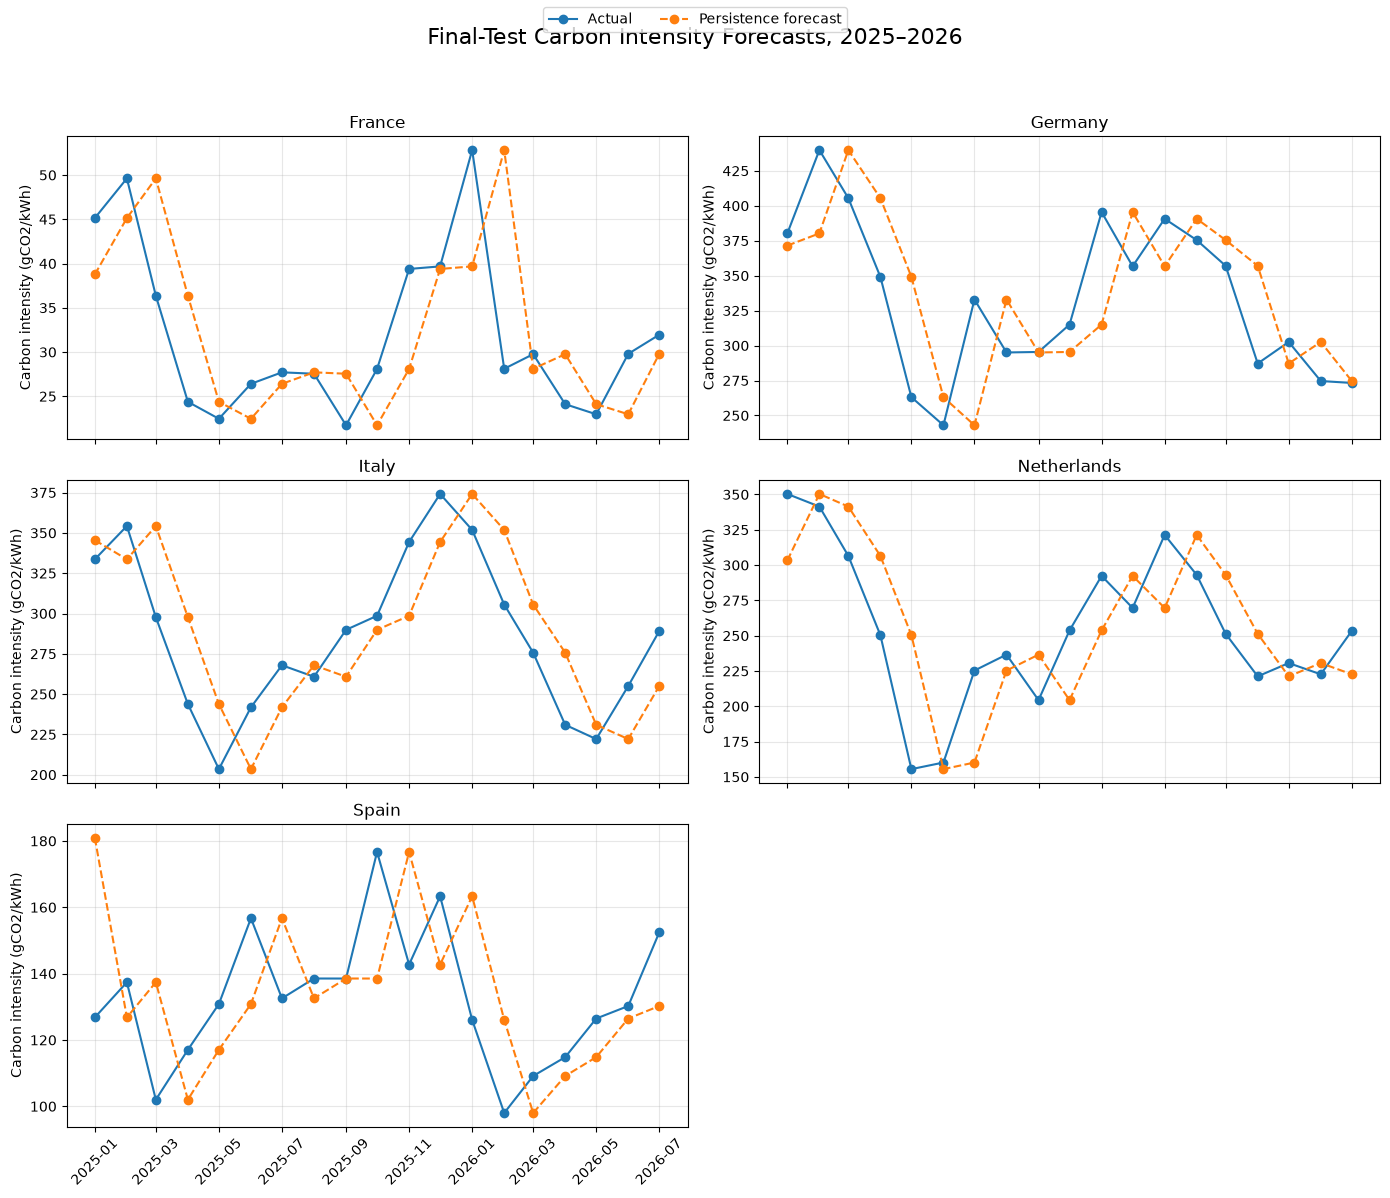

In [35]:
import matplotlib.pyplot as plt


countries = sorted(
    final_test_evaluation["country_name"].unique()
)


fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(14, 12),
    sharex=True
)

axes = axes.flatten()


for axis, country_name in zip(axes, countries):

    country_plot_data = (
        final_test_evaluation.loc[
            final_test_evaluation["country_name"]
            == country_name
        ]
        .sort_values("month")
    )

    axis.plot(
        country_plot_data["month"],
        country_plot_data[
            "carbon_intensity_gco2_per_kwh"
        ],
        marker="o",
        label="Actual"
    )

    axis.plot(
        country_plot_data["month"],
        country_plot_data[
            "carbon_intensity_lag_1"
        ],
        marker="o",
        linestyle="--",
        label="Persistence forecast"
    )

    axis.set_title(country_name)
    axis.set_ylabel("Carbon intensity (gCO2/kWh)")
    axis.grid(alpha=0.3)
    axis.tick_params(
        axis="x",
        rotation=45
    )


for unused_axis in axes[len(countries):]:
    fig.delaxes(unused_axis)


handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2
)

fig.suptitle(
    "Final-Test Carbon Intensity Forecasts, 2025–2026",
    fontsize=16
)

fig.tight_layout(
    rect=[0, 0, 1, 0.95]
)

plt.show()

## Conclusion

This notebook developed and evaluated a leakage-free, one-month-ahead forecasting workflow for monthly electricity carbon intensity across France, Germany, Italy, the Netherlands and Spain.

Historical features were constructed separately within each country using lagged carbon intensity, electricity-mix indicators, demand, import dependence, rolling averages and cyclical calendar variables. All predictors were restricted to information available before the forecast month.

The data were divided chronologically:

- Training: January 2016–December 2022
- Validation: January 2023–December 2024
- Final test: January 2025–July 2026

Ridge, Lasso, Elastic Net, Random Forest and Gradient Boosting models were tuned using expanding-window cross-validation. Model selection was based on validation mean absolute error (MAE). The trained models were also compared with previous-month persistence, seasonal-naive and three-month-average benchmarks.

### Selected method

Previous-month persistence achieved the best validation performance:

- Validation MAE: 23.412 gCO2/kWh
- Validation RMSE: 31.130 gCO2/kWh
- Validation R-squared: 0.938

The selected method was then evaluated once on the untouched final test period:

- Final-test MAE: 26.186 gCO2/kWh
- Final-test RMSE: 33.999 gCO2/kWh
- Final-test R-squared: 0.916

The moderate increase in error indicates some temporal degradation, but no catastrophic loss of performance.

### Interpretation and limitations

Carbon intensity is highly persistent from one month to the next, and the additional relationships learned by the statistical and tree-based models were not stable enough to improve average future error.

The pooled R-squared should be interpreted carefully because differences in average carbon intensity between countries increase the overall value. Country-level performance was weaker, particularly for Germany, the Netherlands and Spain. Persistence also cannot anticipate sudden reversals, shocks or structural changes because it always reacts one month late.

Future improvements could include weather conditions, fuel and electricity prices, generation-capacity changes, country-specific models and probabilistic prediction intervals.